In [2]:
import scanpy as sc
import scipy.io
import pandas as pd
import numpy as np

# 1. Load matrices
counts = scipy.io.mmread("counts.mtx").T.tocsr()
data   = scipy.io.mmread("data.mtx").T.tocsr()

# 2. Load names
barcodes = pd.read_csv("barcodes.csv")["x"].values
features = pd.read_csv("features.csv")["x"].values

# 3. Build AnnData
adata = sc.AnnData(X=counts)
adata.obs_names = barcodes
adata.var_names = features
adata.layers["data"] = data

# 4. Metadata
meta = pd.read_csv("metadata.csv", index_col=0)
meta.index = meta.index.astype(str)
adata.obs = meta.loc[adata.obs_names]

# 5. PCA embeddings (no gene alignment needed)
pca_embed = pd.read_csv("pca_embeddings.csv", index_col=0)
adata.obsm["X_pca"] = pca_embed.loc[adata.obs_names].values

# 6. PCA loadings — align to intersection of genes
pca_load = pd.read_csv("pca_loadings.csv", index_col=0)

shared_genes = adata.var_names.intersection(pca_load.index)
missing = len(pca_load.index) - len(shared_genes)
if missing > 0:
    print(f"Warning: {missing} genes in PCA loadings not in count matrix — filling with 0")

# Build aligned loadings matrix: shape (n_vars, n_PCs)
pca_load_aligned = pd.DataFrame(
    np.zeros((len(adata.var_names), pca_load.shape[1])),
    index=adata.var_names,
    columns=pca_load.columns
)
pca_load_aligned.loc[shared_genes] = pca_load.loc[shared_genes].values
adata.varm["PCs"] = pca_load_aligned.values

# 7. Write
adata.write_h5ad("E16EXC_ST_HEART1.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 59767 × 11031
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'resolution', 'sampleID', 'Spatial_snn_res.0.1', 'seurat_clusters', 'Spatial_snn_res.0.2', 'Spatial_snn_res.0.4'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'data'


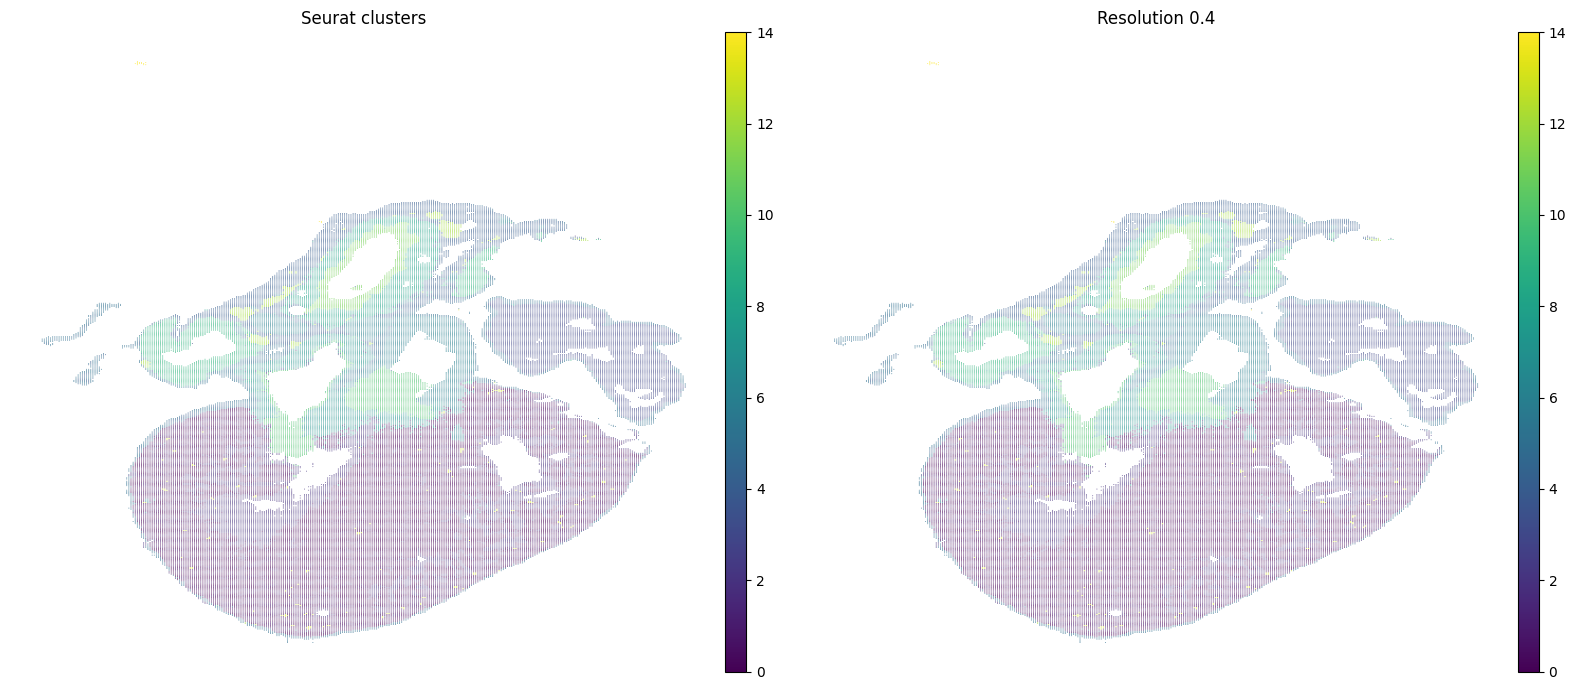

In [7]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

adata = sc.read_h5ad("E16EXC_ST_HEART1.h5ad")

# Parse coordinates from barcode index
# Format: s_008um_RRRRR_CCCCC-1
coords = adata.obs_names.str.extract(r's_008um_(\d+)_(\d+)-')
coords.columns = ["row", "col"]
coords = coords.astype(float)
coords.index = adata.obs_names

adata.obsm["spatial"] = coords[["row", "col"]].values

# Plot by cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc.pl.embedding(
    adata, basis="spatial",
    color="seurat_clusters",
    title="Seurat clusters",
    size=1.5, frameon=False,
    ax=axes[0], show=False
)

sc.pl.embedding(
    adata, basis="spatial",
    color="Spatial_snn_res.0.4",
    title="Resolution 0.4",
    size=1.5, frameon=False,
    ax=axes[1], show=False
)

for ax in axes:
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("spatial_clusters.png", dpi=150, bbox_inches="tight")
plt.show()